# Actividad: Clasificación de clientes para compra de seguro

## Paso 1: Carga y exploración de los datos

In [1]:
# ==============================
# 1. Importar librerías
# ==============================
import pandas as pd

# ==============================
# 2. Cargar el dataset
# ==============================
file_path = "car_insurance.xlsx"

try:
    df = pd.read_excel(file_path)
    print("Dataset cargado correctamente")
except FileNotFoundError:
    print("❌ Error: No se encontró el archivo.")
    print("Verifica que el archivo esté en la misma carpeta que el notebook.")
except Exception as e:
    print("❌ Ocurrió un error al cargar el archivo:")
    print(e)

Dataset cargado correctamente


In [2]:
# ==============================
# 3. Ver primeras filas del dataset
# ==============================
df.head()

,Age,Job,Marital,Education,Default,Balance,HHInsurance,CarLoan,NoOfContacts,PrevAttempts,CarInsurance
0,32,management,single,tertiary,0,1218,1,0,2,0,0
1,32,blue-collar,married,primary,0,1156,1,0,5,0,0
2,29,management,single,tertiary,0,637,1,0,1,1,1
3,25,student,single,primary,0,373,1,0,2,0,1
4,30,management,married,tertiary,0,2694,0,0,1,0,0


In [3]:
# ==============================
# 4. Información general del dataset
# ==============================
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3820 entries, 0 to 3819
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Age           3820 non-null   int64
 1   Job           3820 non-null   str  
 2   Marital       3820 non-null   str  
 3   Education     3820 non-null   str  
 4   Default       3820 non-null   int64
 5   Balance       3820 non-null   int64
 6   HHInsurance   3820 non-null   int64
 7   CarLoan       3820 non-null   int64
 8   NoOfContacts  3820 non-null   int64
 9   PrevAttempts  3820 non-null   int64
 10  CarInsurance  3820 non-null   int64
dtypes: int64(8), str(3)
memory usage: 328.4 KB


In [4]:
# ==============================
# 5. Estadísticas básicas
# ==============================
df.describe()

,Age,Default,Balance,HHInsurance,CarLoan,NoOfContacts,PrevAttempts,CarInsurance
count,3820.000000,3820.000000,3820.000000,3820.000000,3820.000000,3820.000000,3820.000000,3820.000000
mean,41.096335,0.014921,1533.829843,0.498429,0.135079,2.594764,0.715183,0.398168
std,11.362698,0.121255,3502.989359,0.500063,0.341852,3.007658,2.087013,0.489584
min,18.000000,0.000000,-3058.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,32.000000,0.000000,105.750000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,39.000000,0.000000,538.000000,0.000000,0.000000,2.000000,0.000000,0.000000
75%,49.000000,0.000000,1623.000000,1.000000,0.000000,3.000000,0.000000,1.000000
max,95.000000,1.000000,98417.000000,1.000000,1.000000,43.000000,58.000000,1.000000


In [6]:
# ==============================
# 6. Ver proporción de clases
# ==============================
df["CarInsurance"].value_counts(normalize=True)

CarInsurance
0    0.601832
1    0.398168
Name: proportion, dtype: float64

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

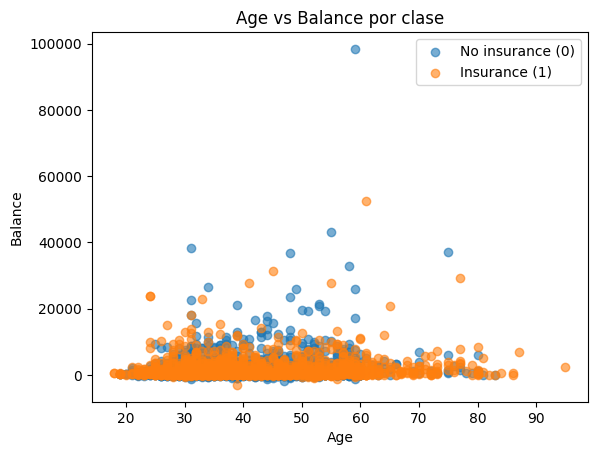

In [13]:
# Separar clases
df_0 = df[df["CarInsurance"] == 0]
df_1 = df[df["CarInsurance"] == 1]

plt.scatter(df_0["Age"], df_0["Balance"], label="No insurance (0)", alpha=0.6)
plt.scatter(df_1["Age"], df_1["Balance"], label="Insurance (1)", alpha=0.6)

plt.xlabel("Age")
plt.ylabel("Balance")
plt.title("Age vs Balance por clase")
plt.legend()
plt.show()

## Paso 2: Preparar los datos

In [14]:
# ==============================
# 1. Separar variables de entrada (X) y variable objetivo (y)
# ==============================

X = df.drop("CarInsurance", axis=1)
y = df["CarInsurance"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (3820, 10)
Dimensiones de y: (3820,)


In [15]:
# Ver primeras filas de X
X.head()

,Age,Job,Marital,Education,Default,Balance,HHInsurance,CarLoan,NoOfContacts,PrevAttempts
0,32,management,single,tertiary,0,1218,1,0,2,0
1,32,blue-collar,married,primary,0,1156,1,0,5,0
2,29,management,single,tertiary,0,637,1,0,1,1
3,25,student,single,primary,0,373,1,0,2,0
4,30,management,married,tertiary,0,2694,0,0,1,0


In [16]:
# Ver primeras filas de y
y.head()

0    0
1    0
2    1
3    1
4    0
Name: CarInsurance, dtype: int64

In [17]:
# ==============================
# 2. Identificar variables numéricas y categóricas en X
# ==============================

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

Variables numéricas:
['Age', 'Default', 'Balance', 'HHInsurance', 'CarLoan', 'NoOfContacts', 'PrevAttempts']

Variables categóricas:
['Job', 'Marital', 'Education']


C:\Users\soporte.sistemas\AppData\Local\Temp\ipykernel_9036\3056531221.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [18]:
# ==============================
# 3. Crear transformaciones
# ==============================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [19]:
# ==============================
# 4. Aplicar transformaciones a X
# ==============================

X_transformed = preprocessor.fit_transform(X)

print("Transformación completada")
print("Tipo de resultado:", type(X_transformed))
print("Dimensiones transformadas:", X_transformed.shape)

Transformación completada
Tipo de resultado: <class 'numpy.ndarray'>
Dimensiones transformadas: (3820, 24)


In [20]:
# ==============================
# 5. Convertir a DataFrame para visualizar el dataset X preparado
# ==============================

encoded_cat_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_names)

X_prepared = pd.DataFrame(X_transformed, columns=all_feature_names)

X_prepared.head()

,Age,Default,Balance,HHInsurance,CarLoan,NoOfContacts,PrevAttempts,Job_admin.,Job_blue-collar,Job_entrepreneur,...,Job_services,Job_student,Job_technician,Job_unemployed,Marital_divorced,Marital_married,Marital_single,Education_primary,Education_secondary,Education_tertiary
0,-0.800648,-0.123075,-0.090172,1.003146,-0.395189,-0.197776,-0.342728,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,-0.800648,-0.123075,-0.107873,1.003146,-0.395189,0.799809,-0.342728,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,-1.064705,-0.123075,-0.256052,1.003146,-0.395189,-0.530304,0.136489,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,-1.416780,-0.123075,-0.331426,1.003146,-0.395189,-0.197776,-0.342728,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,-0.976686,-0.123075,0.331238,-0.996864,-0.395189,-0.530304,-0.342728,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


## Paso 3: Separar datos en entrenamiento y prueba

In [21]:
from sklearn.model_selection import train_test_split

#test_size controla en que proporcion se quiere dividir el conjunto. 0.2 indica 80% entrenamiento y 20% prueba.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (3056, 10)
Test: (764, 10)


## Paso 4: Entrenar modelos de clasificación

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Modelo 1: Logistic Regression
model_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Modelo 2: Decision Tree
model_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# Modelo 3: Random Forest
model_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

# Modelo 4: K-Nearest Neighbors
model_knn = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier())
])

# Entrenar modelos
model_lr.fit(X_train, y_train)
model_dt.fit(X_train, y_train)
model_rf.fit(X_train, y_train)
model_knn.fit(X_train, y_train)

print("✅ Modelos entrenados correctamente")

✅ Modelos entrenados correctamente


## Paso 5: Evaluar resultados y comparar modelos entrenados

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def evaluate_models(models, X_test, y_test):
    results = []
    
    for name, model in models.items():
        y_pred = model.predict(X_test)
        
        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-score": f1_score(y_test, y_pred)
        })
    
    results_df = pd.DataFrame(results)
    return results_df.sort_values(by="F1-score", ascending=False)

models = {
    "Logistic Regression": model_lr,
    "Decision Tree": model_dt,
    "Random Forest": model_rf,
    "KNN": model_knn
}

results_df = evaluate_models(models, X_test, y_test)
results_df

,Model,Accuracy,Precision,Recall,F1-score
2,Random Forest,0.663613,0.600000,0.463816,0.523191
0,Logistic Regression,0.657068,0.600000,0.414474,0.490272
3,KNN,0.620419,0.528926,0.421053,0.468864
1,Decision Tree,0.564136,0.454259,0.473684,0.463768


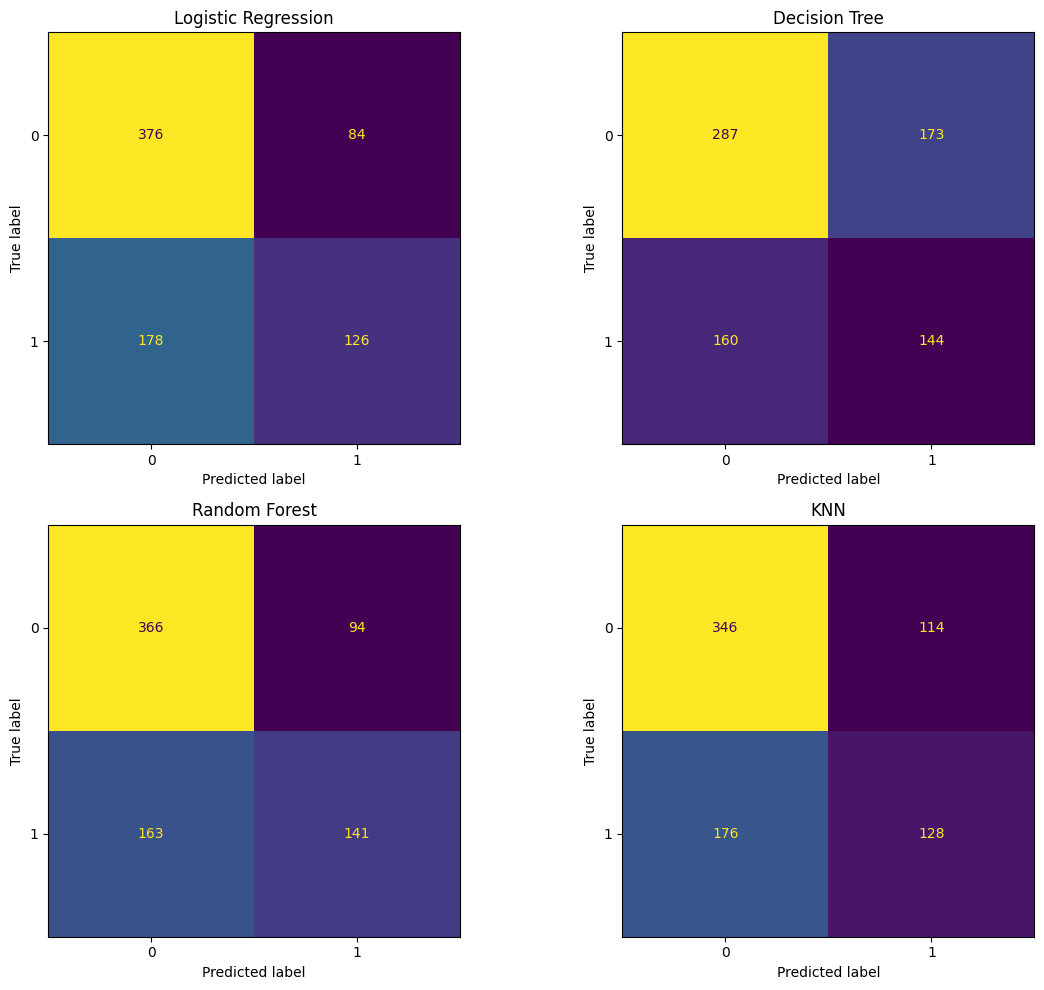

In [24]:
# ==============================
# Podemos visualizar las matrices de confusion para cada modelo
# ==============================
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models_list = list(models.items())

for i, (name, model) in enumerate(models_list):
    row = i // 2
    col = i % 2
    
    ConfusionMatrixDisplay.from_estimator(
        model, 
        X_test, 
        y_test, 
        ax=axes[row, col],
        colorbar=False
    )
    
    axes[row, col].set_title(name)

plt.tight_layout()
plt.show()

## Paso 6: Analizar probabilidades y umbral de clasificación

In [26]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Probabilidades con Logistic Regression
y_proba_lr = model_lr.predict_proba(X_test)[:, 1]

# Cambiar threshold
threshold = 0.3
y_pred_custom = (y_proba_lr >= threshold).astype(int)

print("Threshold seleccionado:", threshold)
print("\nMatriz de confusión con threshold personalizado:")
print(confusion_matrix(y_test, y_pred_custom))

Threshold seleccionado: 0.3

Matriz de confusión con threshold personalizado:
[[187 273]
 [ 60 244]]


## Paso 6: Visualizar curva ROC y AUC

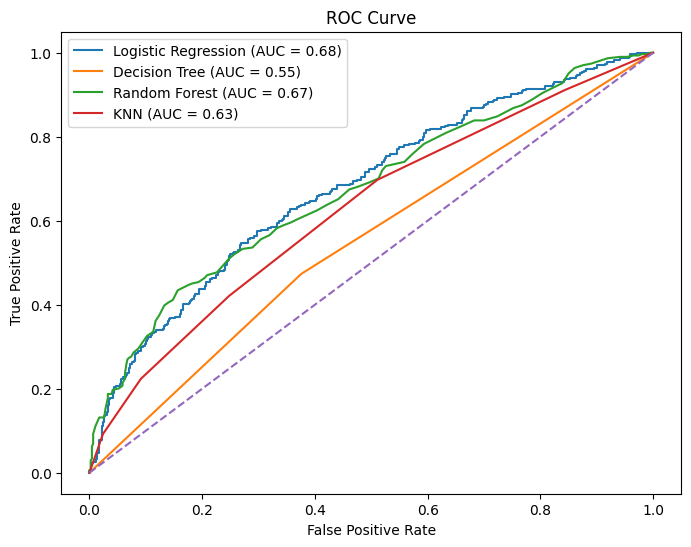

In [27]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": model_lr,
    "Decision Tree": model_dt,
    "Random Forest": model_rf,
    "KNN": model_knn
}

auc_scores = {}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    auc_scores[name] = auc
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Paso 8: Comparar modelos y discutir cuál funciona mejor

In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.657068,0.600000,0.414474,0.490272,0.679148
2,Random Forest,0.663613,0.600000,0.463816,0.523191,0.672948
3,KNN,0.620419,0.528926,0.421053,0.468864,0.626377
1,Decision Tree,0.564136,0.454259,0.473684,0.463768,0.548799
